## Clustering


## Gamma Ray Bursts

Let's try different clustering method to esplore the nature of GRB, starting from how long they last and at which redshifts. We want to answer these questions:
* Does the distribution contain different sub-populations? How many?
* What's the threshold between the classes?
* If you try two clustering methods, do you get more or less the same?
* How do methods respond to outliers?
* What variable(s) shows the multi-modality more evidently?
* Are all GRBs equally likely to be observed?

Answers:
* Depends on the algorithm of choice. After cross validating meanshift gives 2 clusters like kmean.
* Kmeans media distanza centroidi, MeanShift zone a bassa densità (silhouette = 0), GMM equal probability points.
* Tried Kmeans, GMM and MeansShift. The last one is far worst, more subject to outliers, tend to prefer high number of clusters.
* Kmeans is weak to outliers resulting in shifted centroids, Meanshift is weak to outliers resulting in fake isolated clusters.
* In this analysis T90 due to the physical double nature of GRB, long and short.
* Malmquist selection effect

### Data visualization

Dati caricati con successo! Shape: (15, 9175)


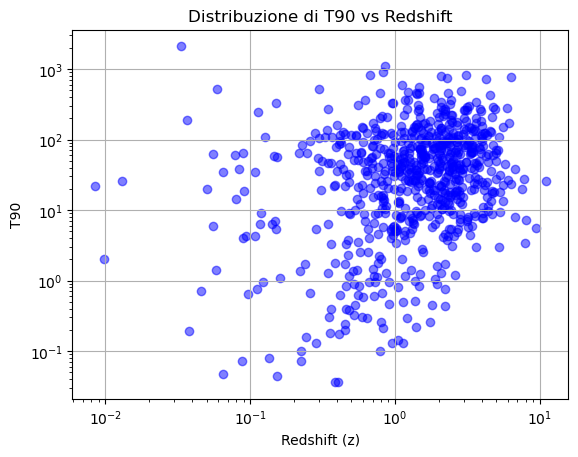

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import io

# 1. Scarica i dati in memoria
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')

# 2. Carica i dati direttamente in NumPy senza salvare nulla su disco
data = np.loadtxt(io.BytesIO(r.content), dtype='str', unpack=True)

print("Dati caricati con successo! Shape:", data.shape)

ra = data[3,:].astype(float)
dec = data[4,:].astype(float)
T90 = data[6,:].astype(float)
flux = data[9,:].astype(float)
err_flux = data[10,:].astype(float)
z = data[11,:].astype(float)

mask = (z != -999) & (T90 != -999)

flux_pulito = flux[mask]
T90_pulito = T90[mask]
ra_pulito = ra[mask]
dec_pulito = dec[mask]
z_pulito = z[mask]

plt.scatter(z_pulito, T90_pulito, alpha=0.5, color='blue')
plt.xlabel('Redshift (z)')
plt.ylabel('T90')
plt.title('Distribuzione di T90 vs Redshift')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

### Kmeans vs MeanShift

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

X = np.column_stack((z_pulito, T90_pulito))
X_log = np.log10(X + 1e-10)

# Split Train/Test
X_train_log, X_test_log, X_train_raw, X_test_raw = train_test_split(X_log, X, test_size=0.2, random_state=42)

# per stima bandwidth mean-shift, preprocess data
scaler_temp = StandardScaler()
X_train_scaled_temp = scaler_temp.fit_transform(X_train_log)

# estimate_bandwidth calcola la distanza media ideale per "raggruppare" i dati, un quantile più piccolo trova più cluster (più locali), uno più grande ne trova meno (più globali).
estimated_bw = estimate_bandwidth(X_train_scaled_temp, quantile=0.2, random_state=42)
print(f"Larghezza di banda stimata per MeanShift: {estimated_bw:.4f}\n")

Larghezza di banda stimata per MeanShift: 0.9872



In [3]:
pipe_kmeans = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42))])

pipe_meanshift = Pipeline([
    ('scaler', StandardScaler()),
    ('meanshift', MeanShift(bandwidth=estimated_bw, bin_seeding=True))])

pipe_meanshift_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('meanshift', MeanShift(bandwidth=1.2256, bin_seeding=True))])

In [4]:
def custom_silhouette_scorer(estimator, X):
    X_scaled = estimator.named_steps['scaler'].transform(X)
    labels = estimator.predict(X)
    n_clusters = len(set(labels))

    if 1 < n_clusters < len(X):
        return silhouette_score(X_scaled, labels)
    else:
        return -1.0 # Penalizza bandwidth che creano 1 solo cluster

bandwidth_grid = np.linspace(0.2, 1.5, 200)
param_grid_ms = {
    'meanshift__bandwidth': bandwidth_grid
}

print("Inizio CV per bandwidth")
grid_search_ms = GridSearchCV(
    estimator=pipe_meanshift,
    param_grid=param_grid_ms,
    scoring=custom_silhouette_scorer,
    cv=3, 
    n_jobs=-1
)

grid_search_ms.fit(X_train_log)
best_bw = grid_search_ms.best_params_['meanshift__bandwidth']
best_pipe_meanshift = grid_search_ms.best_estimator_

print(f"Miglior bandwidth trovata: {best_bw:.4f}")
print(f"Miglior Silhouette Score: {grid_search_ms.best_score_:.4f}\n")

Inizio CV per bandwidth
Miglior bandwidth trovata: 1.2975
Miglior Silhouette Score: 0.5242



In [5]:
# Fit
pipe_kmeans.fit(X_train_log)
pipe_meanshift.fit(X_train_log)

scaler = pipe_kmeans.named_steps['scaler']
kmeans = pipe_kmeans.named_steps['kmeans']
meanshift = pipe_meanshift.named_steps['meanshift']
meanshift_cv = best_pipe_meanshift.named_steps['meanshift']

X_train_scaled = scaler.transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

# Predict (classifica)
labels_km_train = pipe_kmeans.predict(X_train_log)
labels_km_test = pipe_kmeans.predict(X_test_log)

labels_ms_train = pipe_meanshift.predict(X_train_log)
labels_ms_test = pipe_meanshift.predict(X_test_log)

labels_ms_cv_train = best_pipe_meanshift.predict(X_train_log)
labels_ms_cv_test = best_pipe_meanshift.predict(X_test_log)

In [6]:
# numero cluster di meanshift
n_clusters_ms = len(np.unique(labels_ms_train))
n_clusters_ms_cv = len(np.unique(labels_ms_cv_train))
print(f"Il MeanShift ha individuato autonomamente {n_clusters_ms} sotto-popolazioni di GRB.")
print(f"Il MeanShift CV ha individuato {n_clusters_ms_cv} sotto-popolazioni.")

# calcolo silhouette
sil_km_train = silhouette_score(X_train_scaled, labels_km_train)
sil_km_test = silhouette_score(X_test_scaled, labels_km_test)

if n_clusters_ms > 1:
    sil_ms_train = silhouette_score(X_train_scaled, labels_ms_train)
    sil_ms_test = silhouette_score(X_test_scaled, labels_ms_test)
else:
    sil_ms_train, sil_ms_test = np.nan, np.nan
    print("WARNING: MeanShift ha trovato un solo cluster. Impossibile calcolare la Silhouette.")

if n_clusters_ms_cv > 1:
    sil_ms_cv_train = silhouette_score(X_train_scaled, labels_ms_cv_train)
    sil_ms_cv_test = silhouette_score(X_test_scaled, labels_ms_cv_test)
else:
    sil_ms_cv_train, sil_ms_cv_test = np.nan, np.nan
    print("WARNING: MeanShift CV ha trovato un solo cluster.")    

print(f"K-MEANS (K=2) | Silhouette Train: {sil_km_train:.4f} | Test: {sil_km_test:.4f}")
if n_clusters_ms > 1:
    print(f"MEANSHIFT     | Silhouette Train: {sil_ms_train:.4f} | Test: {sil_ms_test:.4f}")
if n_clusters_ms_cv > 1:
    print(f"MEANSHIFT CV   | Silhouette Train: {sil_ms_cv_train:.4f} | Test: {sil_ms_cv_test:.4f}")

# Ritrasformo e estraggo centroidi
centri_km_fisici = 10 ** scaler.inverse_transform(kmeans.cluster_centers_) - 1e-10
centri_ms_fisici = 10 ** scaler.inverse_transform(meanshift.cluster_centers_) - 1e-10
centri_ms_cv_fisici = 10 ** scaler.inverse_transform(meanshift_cv.cluster_centers_) - 1e-10


Il MeanShift ha individuato autonomamente 5 sotto-popolazioni di GRB.
Il MeanShift CV ha individuato 2 sotto-popolazioni.
K-MEANS (K=2) | Silhouette Train: 0.4550 | Test: 0.4521
MEANSHIFT     | Silhouette Train: 0.4169 | Test: 0.4291
MEANSHIFT CV   | Silhouette Train: 0.5429 | Test: 0.5725


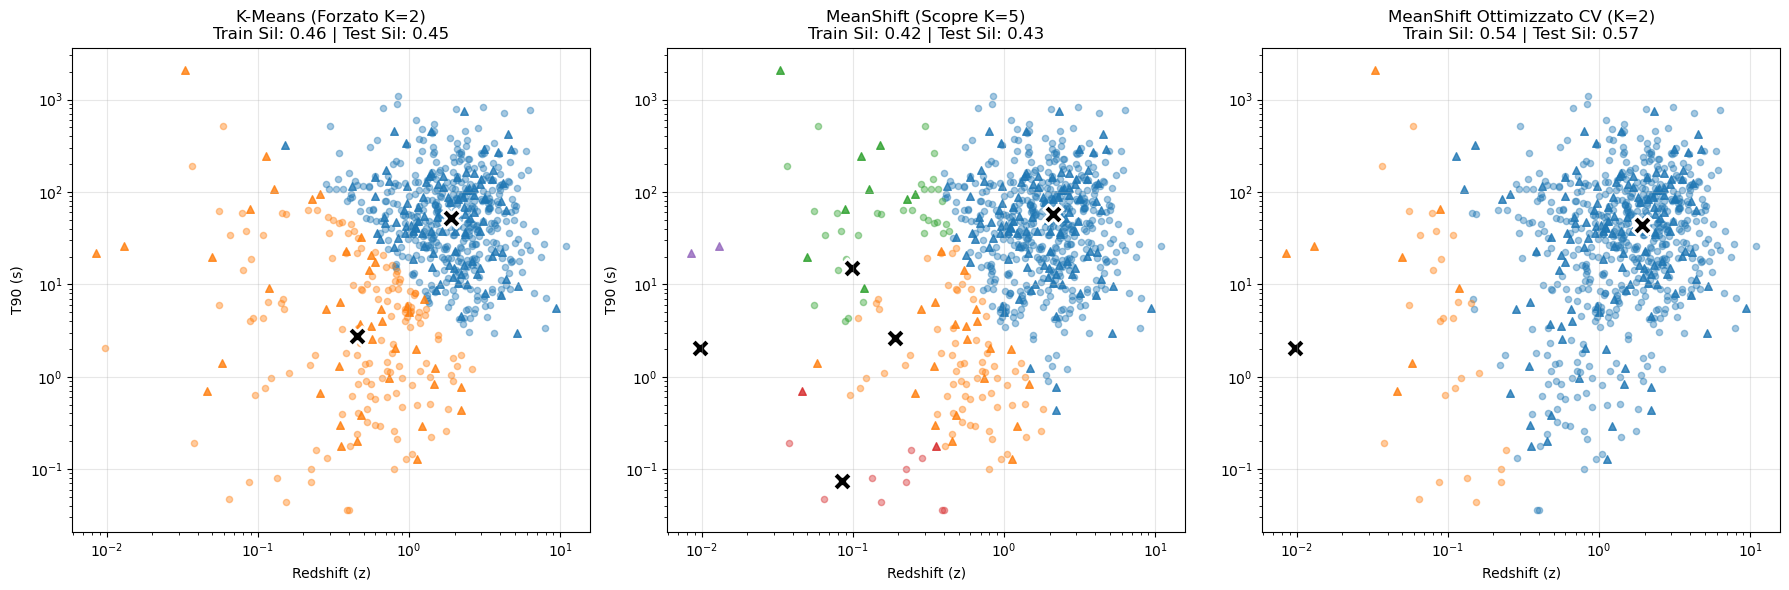

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
colors_palette = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']

for ii in range(2):
    ax1.scatter(X_train_raw[labels_km_train==ii, 0], X_train_raw[labels_km_train==ii, 1], 
                color=colors_palette[ii], alpha=0.4, s=20, label=f'Train Cluster {ii}')
    ax1.scatter(X_test_raw[labels_km_test==ii, 0], X_test_raw[labels_km_test==ii, 1], 
                color=colors_palette[ii], marker='^', alpha=0.8, s=30, label=f'Test Cluster {ii}')
ax1.scatter(centri_km_fisici[:, 0], centri_km_fisici[:, 1], 
            marker='X', s=200, color='black', edgecolors='white', linewidths=2, label='Centroidi K-Means')
ax1.set_title(f'K-Means (Forzato K=2)\nTrain Sil: {sil_km_train:.2f} | Test Sil: {sil_km_test:.2f}')
ax1.set_xlabel('Redshift (z)')
ax1.set_ylabel('T90 (s)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

for ii in range(n_clusters_ms):
    ax2.scatter(X_train_raw[labels_ms_train==ii, 0], X_train_raw[labels_ms_train==ii, 1], 
                color=colors_palette[ii % len(colors_palette)], alpha=0.4, s=20, label=f'Train Cluster {ii}')
    ax2.scatter(X_test_raw[labels_ms_test==ii, 0], X_test_raw[labels_ms_test==ii, 1], 
                color=colors_palette[ii % len(colors_palette)], marker='^', alpha=0.8, s=30, label=f'Test Cluster {ii}')
if n_clusters_ms > 0:
    ax2.scatter(centri_ms_fisici[:, 0], centri_ms_fisici[:, 1], 
                marker='X', s=200, color='black', edgecolors='white', linewidths=2, label='Centri MeanShift')
ax2.set_title(f'MeanShift (Scopre K={n_clusters_ms})\nTrain Sil: {sil_ms_train:.2f} | Test Sil: {sil_ms_test:.2f}')
ax2.set_xlabel('Redshift (z)')
ax2.set_ylabel('T90 (s)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

for ii in range(n_clusters_ms_cv):
    ax3.scatter(X_train_raw[labels_ms_cv_train==ii, 0], X_train_raw[labels_ms_cv_train==ii, 1], 
                color=colors_palette[ii % len(colors_palette)], alpha=0.4, s=20)
    ax3.scatter(X_test_raw[labels_ms_cv_test==ii, 0], X_test_raw[labels_ms_cv_test==ii, 1], 
                color=colors_palette[ii % len(colors_palette)], marker='^', alpha=0.8, s=30)
if n_clusters_ms_cv > 0:
    ax3.scatter(centri_ms_cv_fisici[:, 0], centri_ms_cv_fisici[:, 1], 
                marker='X', s=200, color='black', edgecolors='white', linewidths=2)
ax3.set_title(f'MeanShift Ottimizzato CV (K={n_clusters_ms_cv})\nTrain Sil: {sil_ms_cv_train:.2f} | Test Sil: {sil_ms_cv_test:.2f}')
ax3.set_xlabel('Redshift (z)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Use Crossvalidated Bandwidth

#### Definizione dello Score di Silhouette

La **Silhouette** è una metrica di validazione interna per algoritmi di clustering che misura quanto un punto sia simile al proprio cluster (coesione) rispetto agli altri cluster (separazione). Per ogni punto $i$ del dataset, il coefficiente di Silhouette $s_i$ viene calcolato combinando due distanze medie:

*   **Coesione ($a_i$)**: La distanza media tra il punto $i$ e tutti gli altri punti appartenenti allo **stesso cluster**. Rappresenta la compattezza del gruppo (vogliamo que sia minima).
*   **Separazione ($b_i$)**: La distanza media tra il punto $i$ e tutti i punti del **cluster vicino più prossimo** (ovvero il cluster non suo che è geograficamente più vicino). Rappresenta la distanza dal confine (vogliamo che sia massima).

La formula per il singolo punto $i$ è:
$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$

Lo score di Silhouette globale del dataset è la media aritmetica di tutti i coefficienti $s_i$. Il valore ottenuto oscilla sempre nell'intervallo $[-1, 1]$:
*   **$s \approx +1$**: Ottimo clustering. I punti sono vicini ai membri del proprio gruppo e lontani dagli altri.
*   **$s \approx 0$**: Struttura sovrapposta. I punti giacciono sul confine decisionale tra due o più cluster.
*   **$s \approx -1$**: Clustering errato. I punti sono più vicini a un cluster adiacente rispetto a quello a cui sono stati effettivamente assegnati.



### Explore Bimodality

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/var/folders/df/8kzdlh4s5fb1h6n2cfc7y5fw0000gn/T/ipykernel_3765/2681007106.py:17: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(T_{90})$ [s]', fontsize=12)


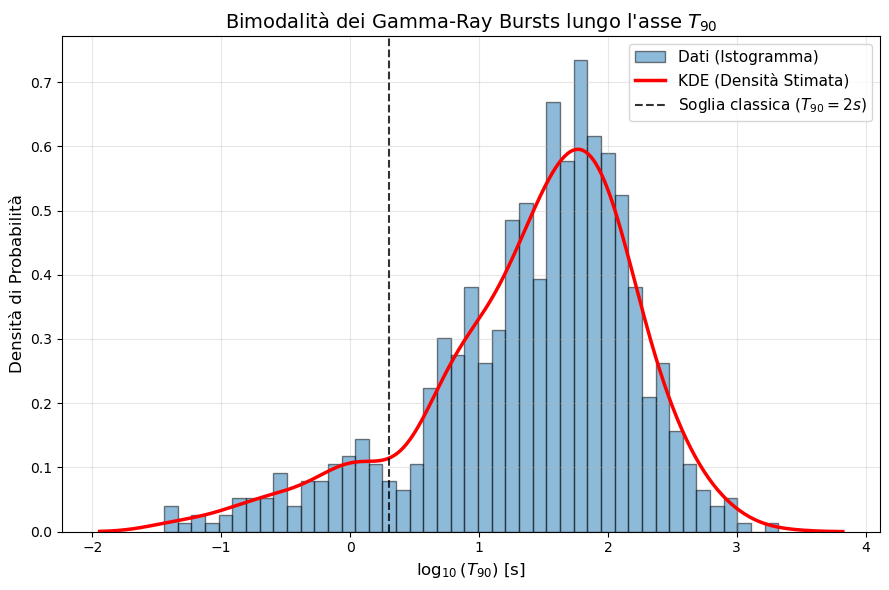

Exception ignored in: <function ResourceTracker.__del__ at 0x105a39f80>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104c59f80>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1063e5f80>
Traceback (most recent call last

In [ ]:
from scipy.stats import gaussian_kde
mask_T90_valido = T90_pulito > 0
T90_valido = T90_pulito[mask_T90_valido]
log_T90 = np.log10(T90_valido)

#kde, usa scott rule
x_T90 = np.linspace(log_T90.min() - 0.5, log_T90.max() + 0.5, 500)
kde_T90 = gaussian_kde(log_T90)
pdf_T90 = kde_T90(x_T90)

plt.figure(figsize=(9, 6))
plt.hist(log_T90, bins=45, density=True, alpha=0.5, color='C0', edgecolor='black', label='Dati (Istogramma)')
plt.plot(x_T90, pdf_T90, color='red', lw=2.5, label='KDE (Densità Stimata)')
plt.axvline(x=np.log10(2), color='k', linestyle='--', alpha=0.8, label='Soglia classica ($T_{90} = 2s$)')

plt.title('Bimodalità dei Gamma-Ray Bursts lungo l\'asse $T_{90}$', fontsize=14)
plt.xlabel('$\log_{10}(T_{90})$ [s]', fontsize=12)
plt.ylabel('Densità di Probabilità', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()